Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")


Load Dataset

In [ ]:
# Load dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Display first five rows
print(df.head())

print("\nShape of Dataset:", df.shape)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

Dataset Information

In [ ]:
print(df.info())

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Remove Duplicate Records

In [ ]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (1470, 35)


Remove Unnecessary Features

In [ ]:
constant_columns = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_columns.append(col)

print("Constant Columns:")
print(constant_columns)

Constant Columns:
['EmployeeCount', 'Over18', 'StandardHours']


In [ ]:
df.drop(columns=constant_columns, inplace=True)

Remove Employee Number

In [ ]:
df.drop("EmployeeNumber", axis=1, inplace=True)

Check Target Distribution

In [ ]:
print(df["Attrition"].value_counts())

print(df["Attrition"].value_counts(normalize=True)*100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


Encode Target Variable

In [ ]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

Identify Categorical Columns

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


Label Encode Binary Variables

In [ ]:
binary_cols = [
    "Gender",
    "OverTime"
]

encoder = LabelEncoder()

for col in binary_cols:
    df[col] = encoder.fit_transform(df[col])

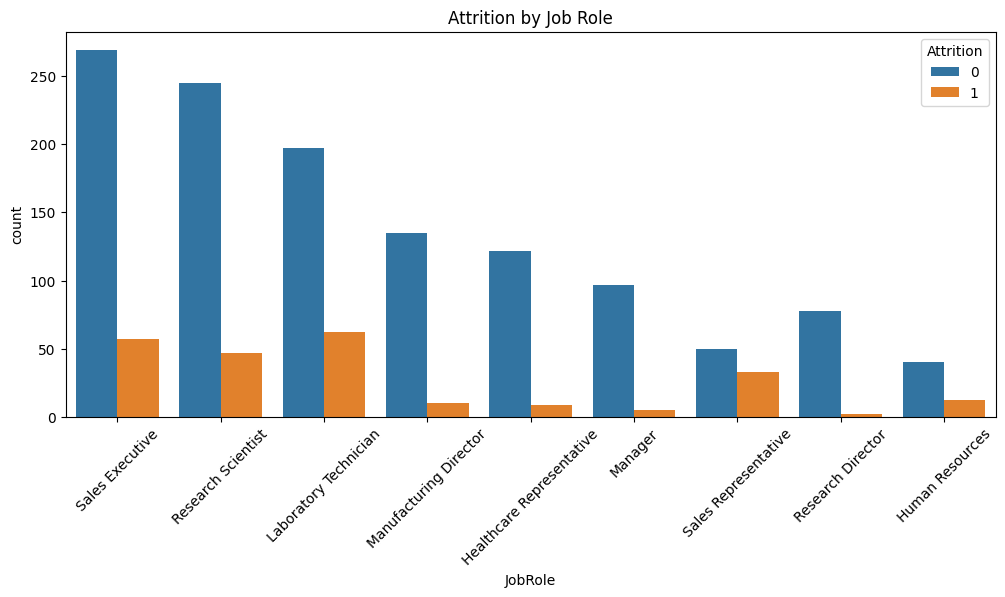

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Job Role")
plt.show()

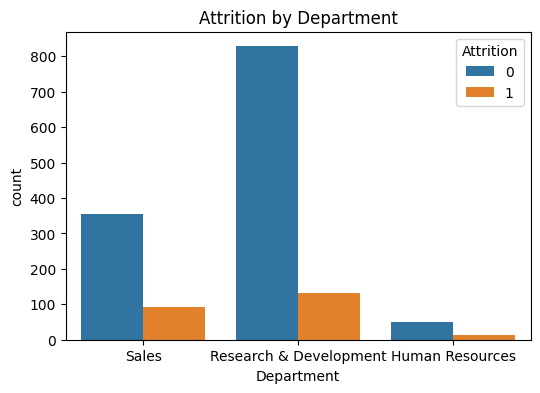

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title("Attrition by Department")
plt.show()

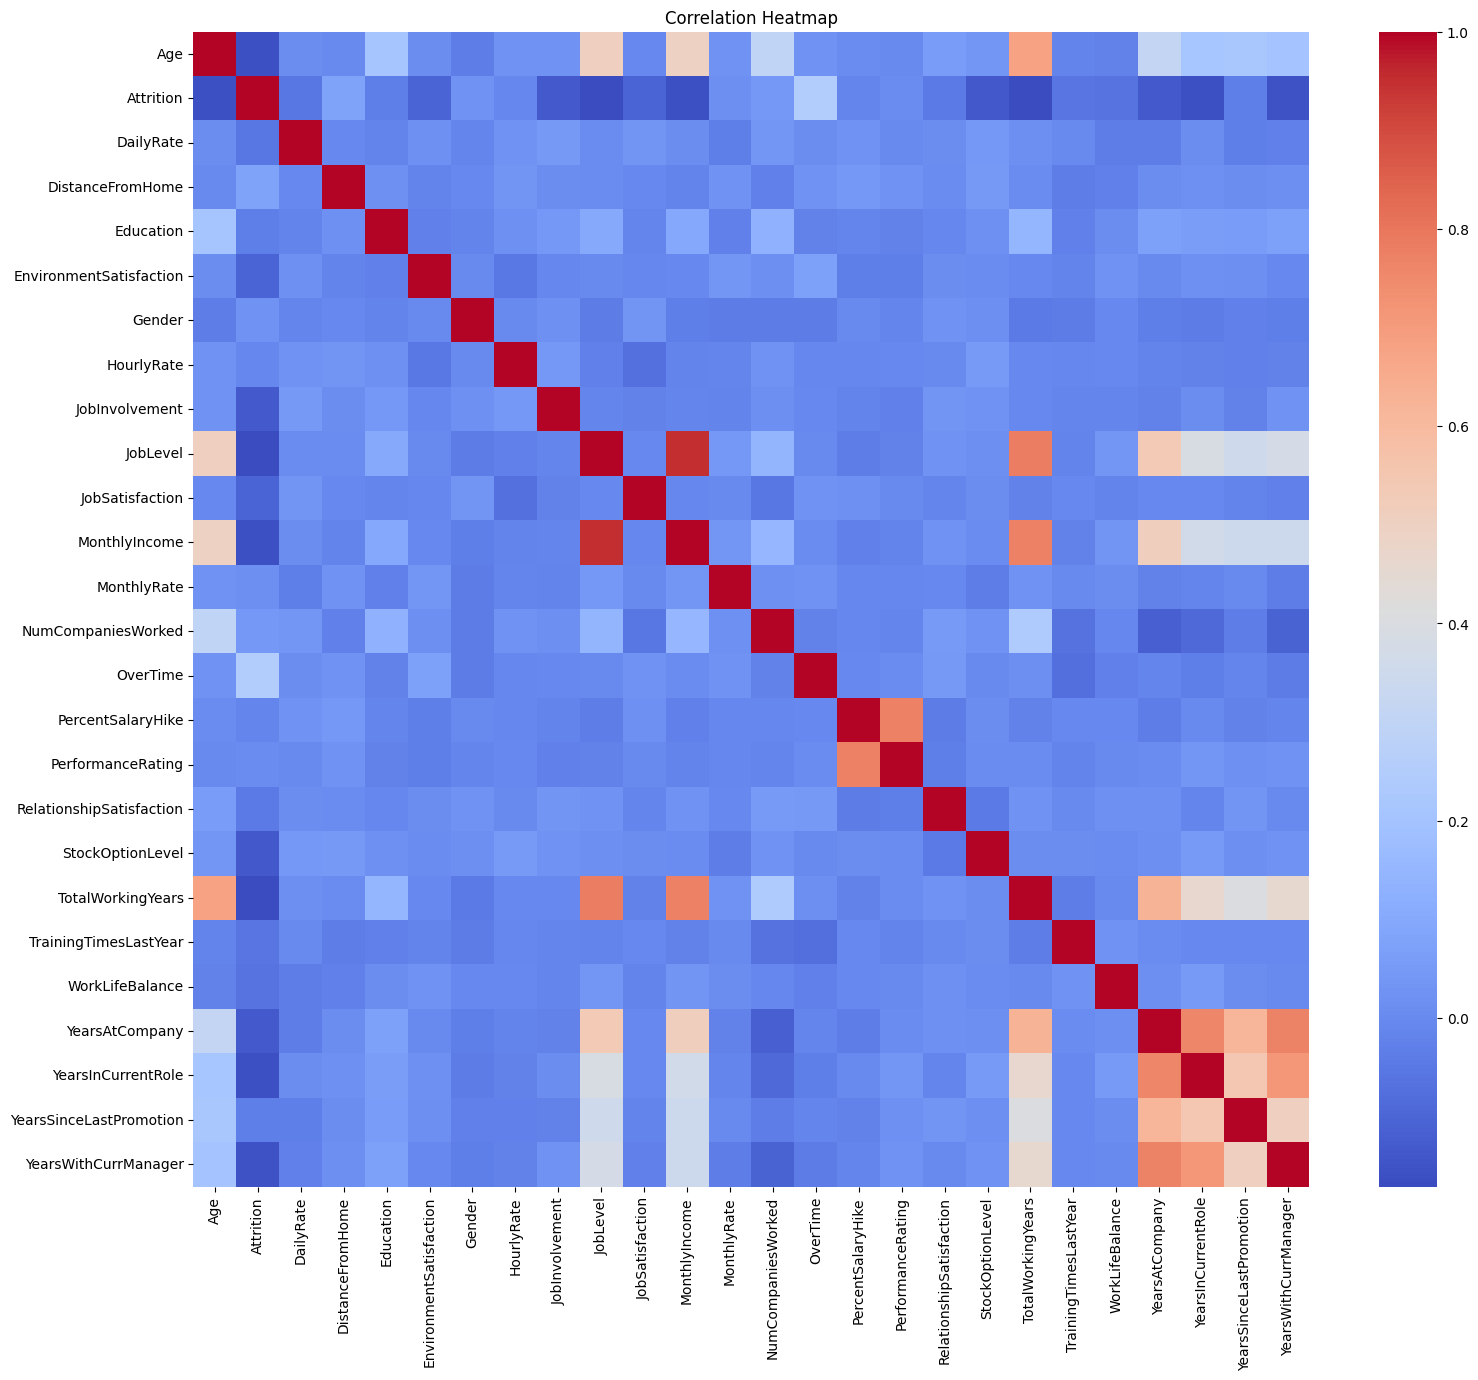

In [ ]:
plt.figure(figsize=(18,15))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

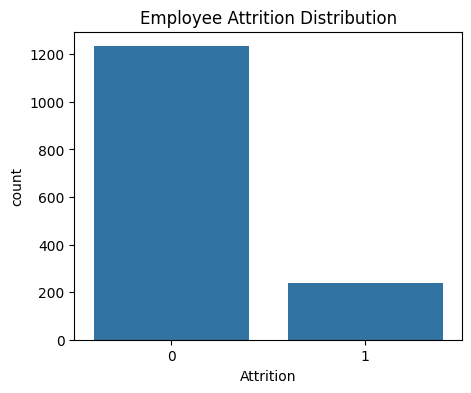

In [ ]:

plt.figure(figsize=(5,4))
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

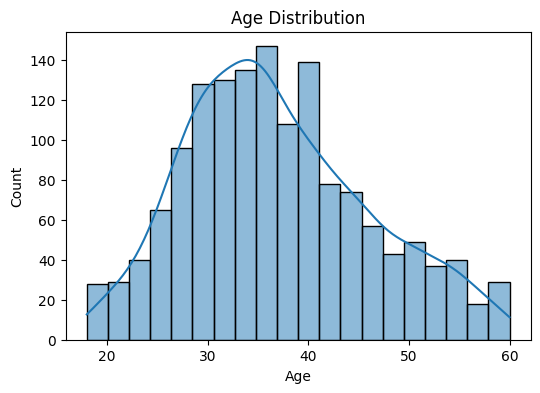

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

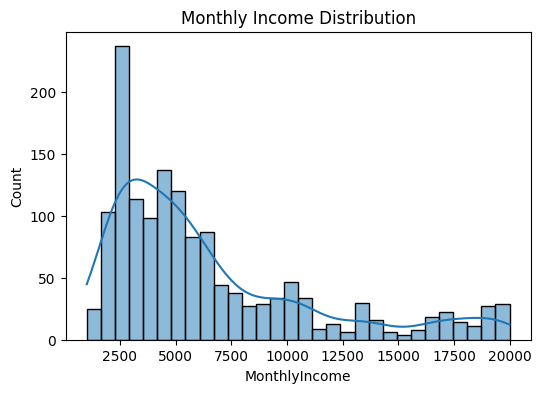

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True)
plt.title("Monthly Income Distribution")
plt.show()

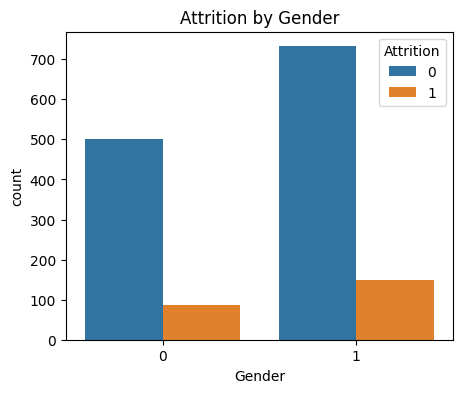

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Gender', hue='Attrition', data=df)
plt.title("Attrition by Gender")
plt.show()

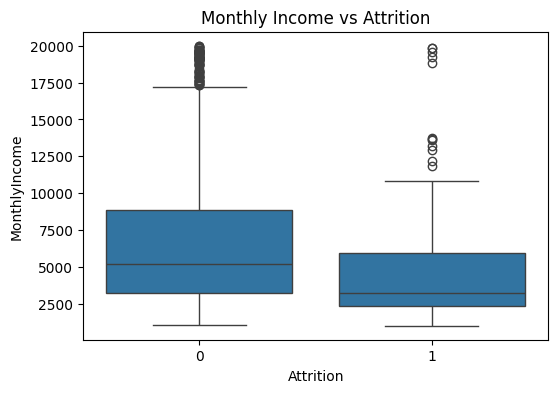

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

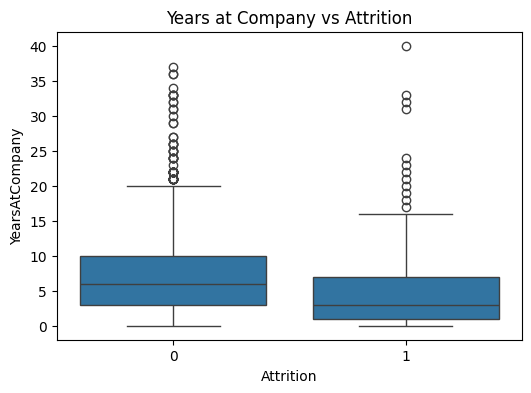

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title("Years at Company vs Attrition")
plt.show()

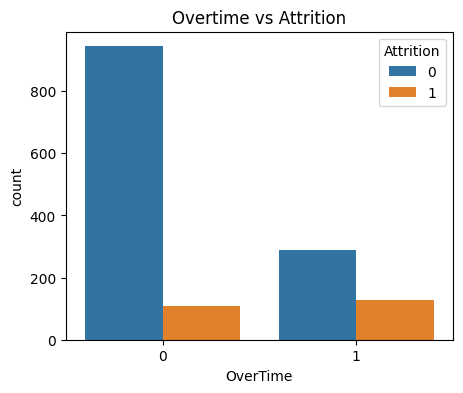

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Overtime vs Attrition")
plt.show()

One-Hot Encode Remaining Categorical Variables

In [ ]:
multi_class_cols = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus"
]

df = pd.get_dummies(
    df,
    columns=multi_class_cols,
    drop_first=True
)

Separate Features and Target

In [ ]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Verify Shapes

In [ ]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1176, 44)
Testing Features  : (294, 44)
Training Labels   : (1176,)
Testing Labels    : (294,)


Save Processed Data (Optional)

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_test, "X_test.pkl")

joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']

In [ ]:
print(df.describe())


               Age    Attrition    DailyRate  DistanceFromHome    Education  \
count  1470.000000  1470.000000  1470.000000       1470.000000  1470.000000   
mean     36.923810     0.161224   802.485714          9.192517     2.912925   
std       9.135373     0.367863   403.509100          8.106864     1.024165   
min      18.000000     0.000000   102.000000          1.000000     1.000000   
25%      30.000000     0.000000   465.000000          2.000000     2.000000   
50%      36.000000     0.000000   802.000000          7.000000     3.000000   
75%      43.000000     0.000000  1157.000000         14.000000     4.000000   
max      60.000000     1.000000  1499.000000         29.000000     5.000000   

       EnvironmentSatisfaction       Gender   HourlyRate  JobInvolvement  \
count              1470.000000  1470.000000  1470.000000     1470.000000   
mean                  2.721769     0.600000    65.891156        2.729932   
std                   1.093082     0.490065    20.329428    

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.8605442176870748

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294


Confusion Matrix
[[237  10]
 [ 31  16]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7551020408163265

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       247
           1       0.29      0.36      0.32        47

    accuracy                           0.76       294
   macro avg       0.58      0.60      0.59       294
weighted avg       0.78      0.76      0.77       294


Confusion Matrix:
[[205  42]
 [ 30  17]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8333333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294


Confusion Matrix:
[[241   6]
 [ 43   4]]


In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.8673469387755102

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       247
           1       0.90      0.19      0.32        47

    accuracy                           0.87       294
   macro avg       0.88      0.59      0.62       294
weighted avg       0.87      0.87      0.83       294


Confusion Matrix:
[[246   1]
 [ 38   9]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.8469387755102041

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294


Confusion Matrix:
[[244   3]
 [ 42   5]]


In [ ]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

import pandas as pd

results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])

print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
3                  SVM  0.867347
0  Logistic Regression  0.860544
4                  KNN  0.846939
2        Random Forest  0.833333
1        Decision Tree  0.755102


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

results = []

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn
}

predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn
}

for name in models:

    model = models[name]
    pred = predictions[name]

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
    else:
        prob = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,SVM,0.867347,0.900000,0.191489,0.315789,0.812904
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356,0.807908
4,KNN,0.846939,0.625000,0.106383,0.181818,0.636101
2,Random Forest,0.833333,0.400000,0.085106,0.140351,0.785425
1,Decision Tree,0.755102,0.288136,0.361702,0.320755,0.595831


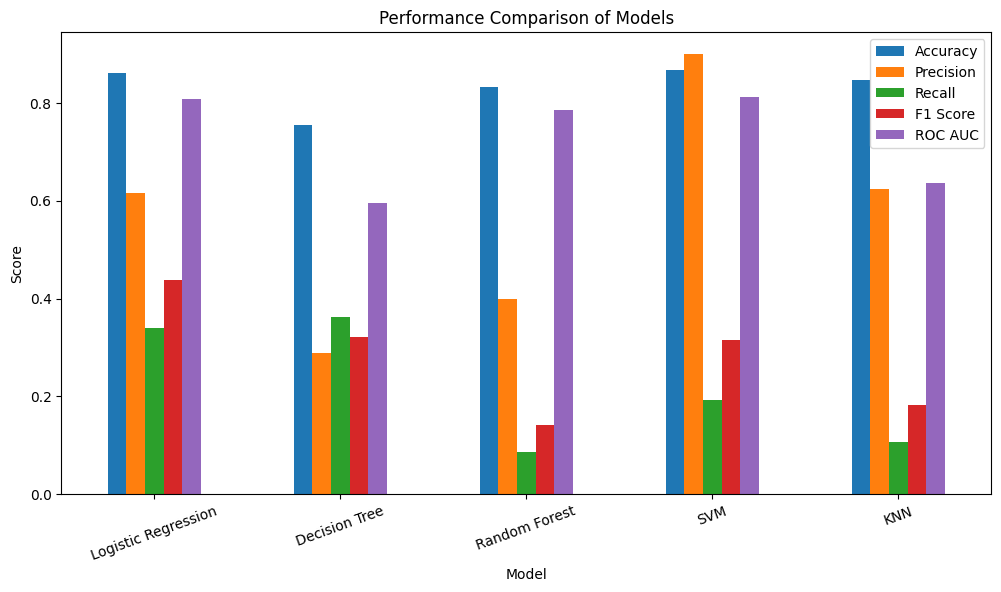

In [ ]:
metrics = results_df.set_index("Model")

metrics.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Performance Comparison of Models")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


importance = rf.feature_importances_


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})


feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

               Feature  Importance
10       MonthlyIncome    0.073461
0                  Age    0.060790
18   TotalWorkingYears    0.060715
1            DailyRate    0.053532
11         MonthlyRate    0.051456
2     DistanceFromHome    0.046891
6           HourlyRate    0.046550
21      YearsAtCompany    0.040459
13            OverTime    0.039733
12  NumCompaniesWorked    0.036604


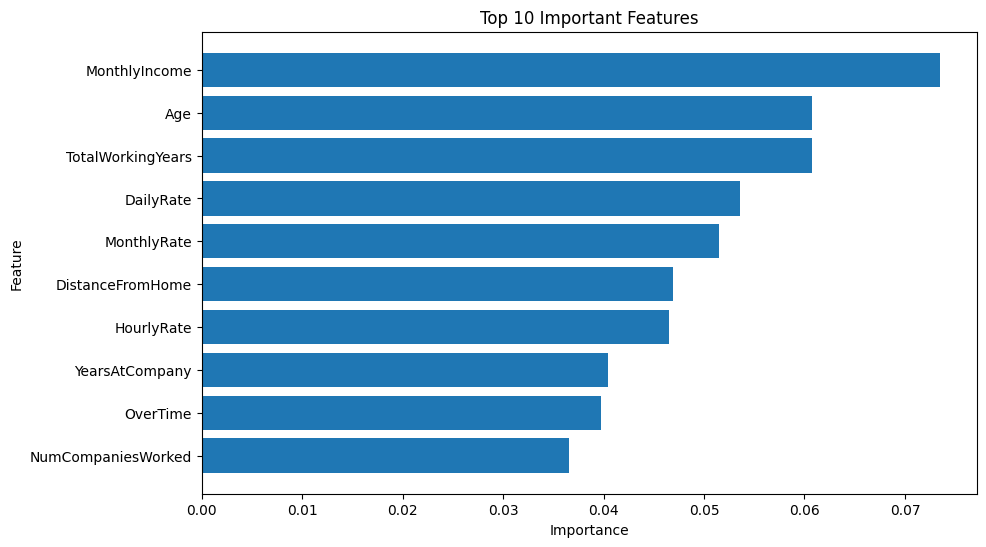

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(feature_importance['Feature'][:10],
         feature_importance['Importance'][:10])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
prediction = rf.predict(X_test)

print("First 10 Predictions:")
print(prediction[:10])

print("Actual Values:")
print(y_test.values[:10])

First 10 Predictions:
[1 0 0 0 0 0 0 0 0 0]
Actual Values:
[0 0 0 0 1 0 0 0 0 0]


In [ ]:
import joblib

joblib.dump(rf, "employee_attrition_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load("employee_attrition_model.pkl")

prediction = loaded_model.predict(X_test)

print(prediction[:5])

[1 0 0 0 0]


Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# ---------------- Logistic Regression ----------------

lr_params = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train,y_train)

best_lr = grid_lr.best_estimator_

print("Best Logistic Regression Parameters")
print(grid_lr.best_params_)



# ---------------- Random Forest ----------------

rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train,y_train)

best_rf = grid_rf.best_estimator_

print("\nBest Random Forest Parameters")
print(grid_rf.best_params_)



# ---------------- SVM ----------------

svm_params = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf'],
    'gamma':['scale','auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train,y_train)

best_svm = grid_svm.best_estimator_

print("\nBest SVM Parameters")
print(grid_svm.best_params_)

Best Logistic Regression Parameters
{'C': 10, 'solver': 'lbfgs'}

Best Random Forest Parameters
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best SVM Parameters
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


Train Tuned Models

In [ ]:
y_pred_lr_best = best_lr.predict(X_test)
y_pred_rf_best = best_rf.predict(X_test)
y_pred_svm_best = best_svm.predict(X_test)

Compare Tuned Models

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

tuned_results = []

models = {
    "Logistic Regression":(best_lr,y_pred_lr_best),
    "Random Forest":(best_rf,y_pred_rf_best),
    "SVM":(best_svm,y_pred_svm_best)
}

for name,(model,pred) in models.items():

    prob = model.predict_proba(X_test)[:,1]

    tuned_results.append({

        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1 Score":f1_score(y_test,pred),
        "ROC AUC":roc_auc_score(y_test,prob)

    })

tuned_df = pd.DataFrame(tuned_results)

tuned_df = tuned_df.sort_values(by="Accuracy",ascending=False)

tuned_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,SVM,0.867347,0.666667,0.340426,0.450704,0.810750
0,Logistic Regression,0.857143,0.592593,0.340426,0.432432,0.806788
1,Random Forest,0.840136,0.500000,0.085106,0.145455,0.793695


Compare Before vs After Tuning

In [ ]:
before = results_df[
    results_df["Model"].isin([
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ])
].copy()

before["Version"] = "Before"

after = tuned_df.copy()
after["Version"] = "After"

comparison = pd.concat([before,after])

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Version
0,Logistic Regression,0.860544,0.615385,0.340426,0.438356,0.807908,Before
2,Random Forest,0.833333,0.400000,0.085106,0.140351,0.785425,Before
3,SVM,0.867347,0.900000,0.191489,0.315789,0.812904,Before
2,SVM,0.867347,0.666667,0.340426,0.450704,0.810750,After
0,Logistic Regression,0.857143,0.592593,0.340426,0.432432,0.806788,After
1,Random Forest,0.840136,0.500000,0.085106,0.145455,0.793695,After


Plot Before vs After

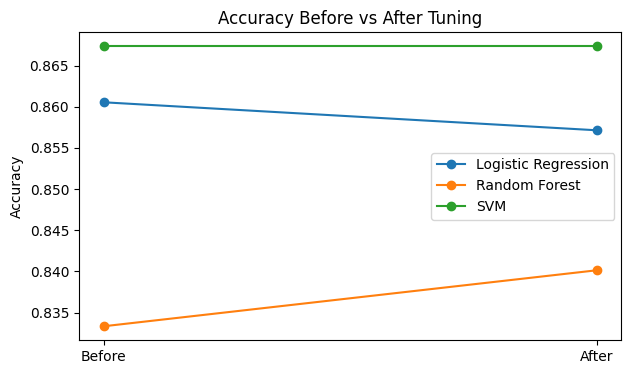

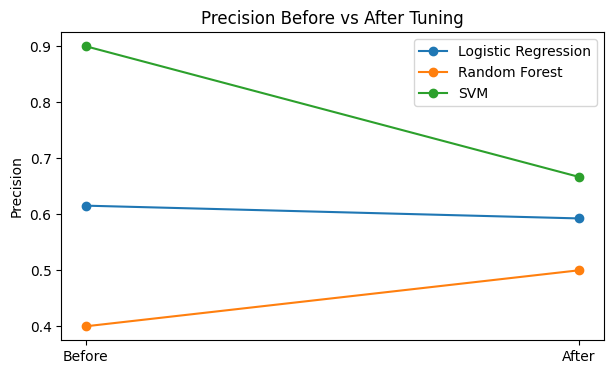

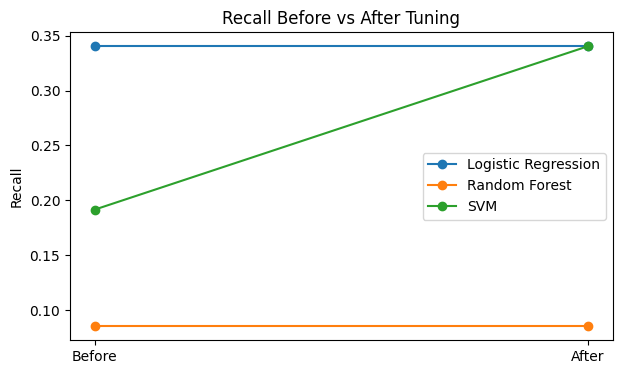

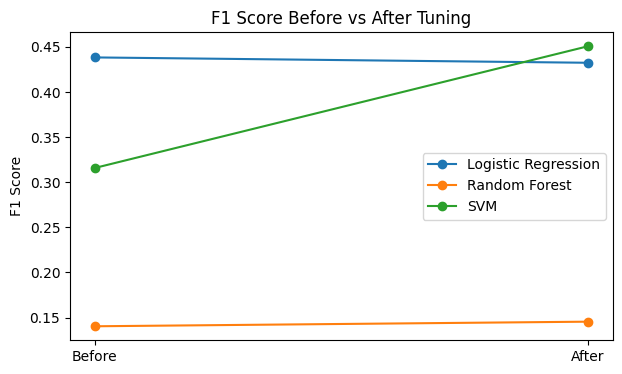

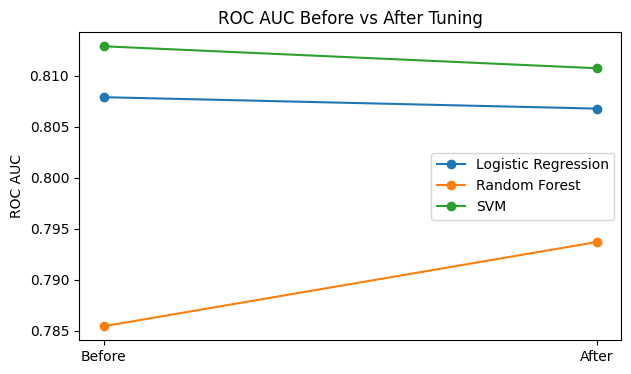

In [ ]:
metrics = ["Accuracy","Precision","Recall","F1 Score","ROC AUC"]

for metric in metrics:

    plt.figure(figsize=(7,4))

    for model in comparison["Model"].unique():

        values = comparison[comparison["Model"]==model]

        plt.plot(
            values["Version"],
            values[metric],
            marker="o",
            label=model
        )

    plt.title(metric+" Before vs After Tuning")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

Choose Final Model

In [ ]:
print(tuned_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2                  SVM  0.867347   0.666667  0.340426  0.450704  0.810750
0  Logistic Regression  0.857143   0.592593  0.340426  0.432432  0.806788
1        Random Forest  0.840136   0.500000  0.085106  0.145455  0.793695


Install SHAP

In [ ]:
!pip install shap

Import Libraries

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

Create SHAP Explainer

In [ ]:
explainer = shap.Explainer(best_svm.predict, X_train)

Calculate SHAP Values

In [ ]:
shap_values = explainer(X_test)

PermutationExplainer explainer: 295it [02:41,  1.82it/s]


SHAP Summary Plot

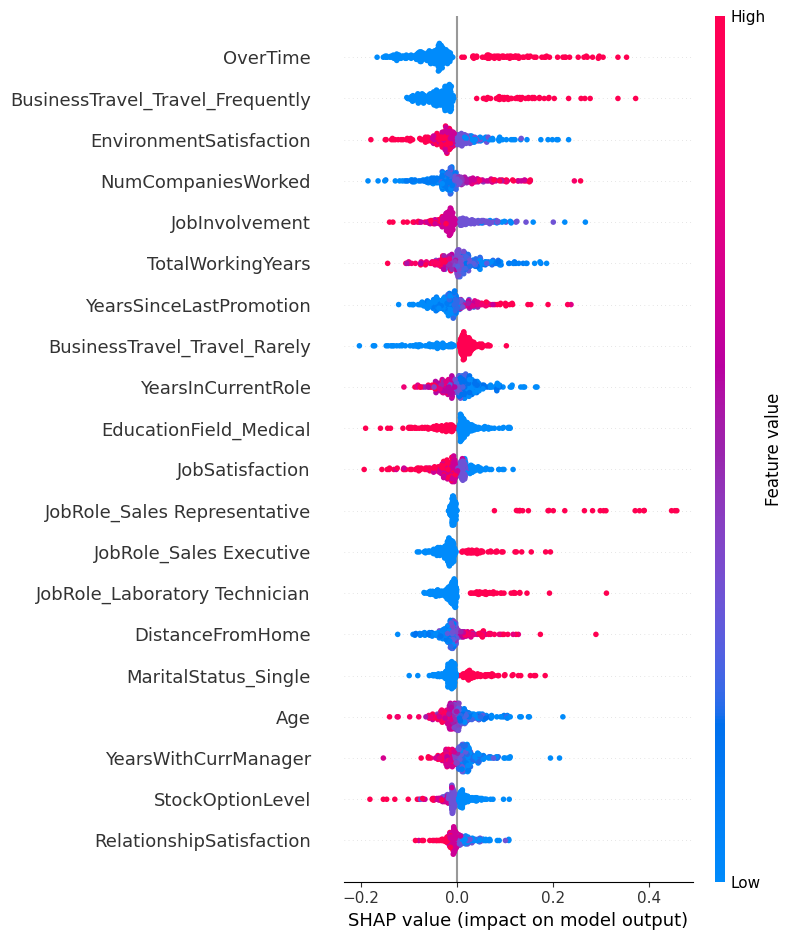

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

SHAP Feature Importance

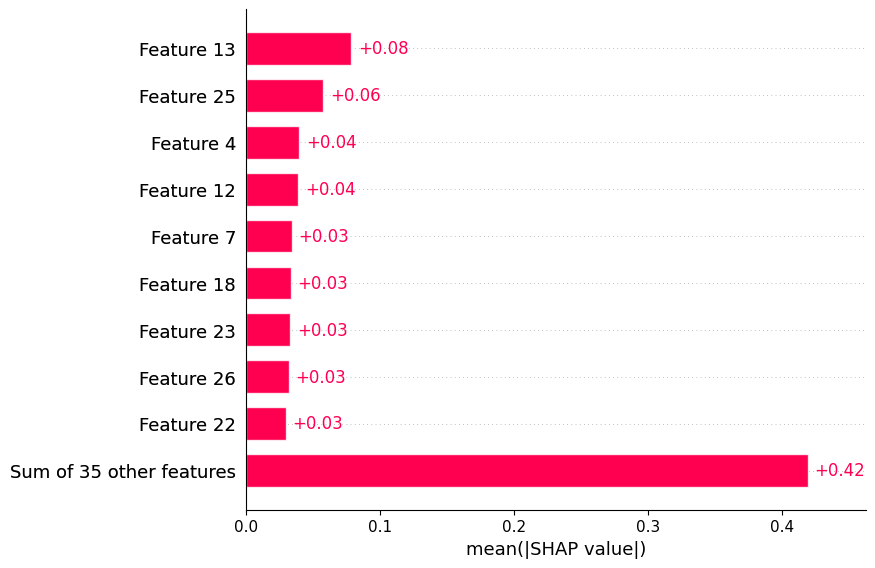

In [ ]:
shap.plots.bar(shap_values)

Explain One Employee

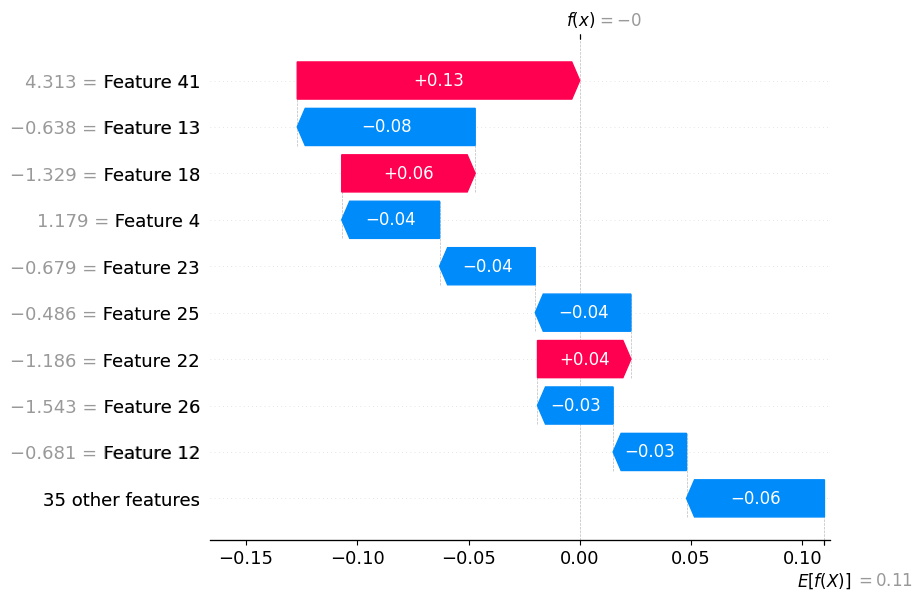

In [ ]:
shap.plots.waterfall(shap_values[0])

Streamlit

In [ ]:
import joblib

# 'X' is the DataFrame before scaling, which still has the column names.
# We extract the columns and convert them to a standard Python list.
expected_columns = X.columns.tolist()

# Save this list to a new file
joblib.dump(expected_columns, "expected_columns.pkl")

['expected_columns.pkl']